Saved 20074 total rows → data/non-linear-voters.csv
Real: 74  |  Synthetic: 20000
   (5000 voters × 4 country snapshots)

Feature columns: 25
Target columns:  9

Target averages across all country contexts:
  probability_take_part                          mean=61.54  std=30.43
  candidate_positive_importance                  mean=4.85  std=1.95
  candidate_negative_fair_importance             mean=7.73  std=1.92
  like_easy_decision                             mean=5.83  std=1.81
  like_strong_leader_over_law                    mean=3.11  std=1.12
  understand_government_institutions             mean=5.56  std=2.21
  every_person_is_expert                         mean=2.30  std=1.14
  person_or_government_importance                mean=5.31  std=2.17
  believe_government_institutions                mean=4.04  std=3.13
Розподіл усіх вихідних колонок


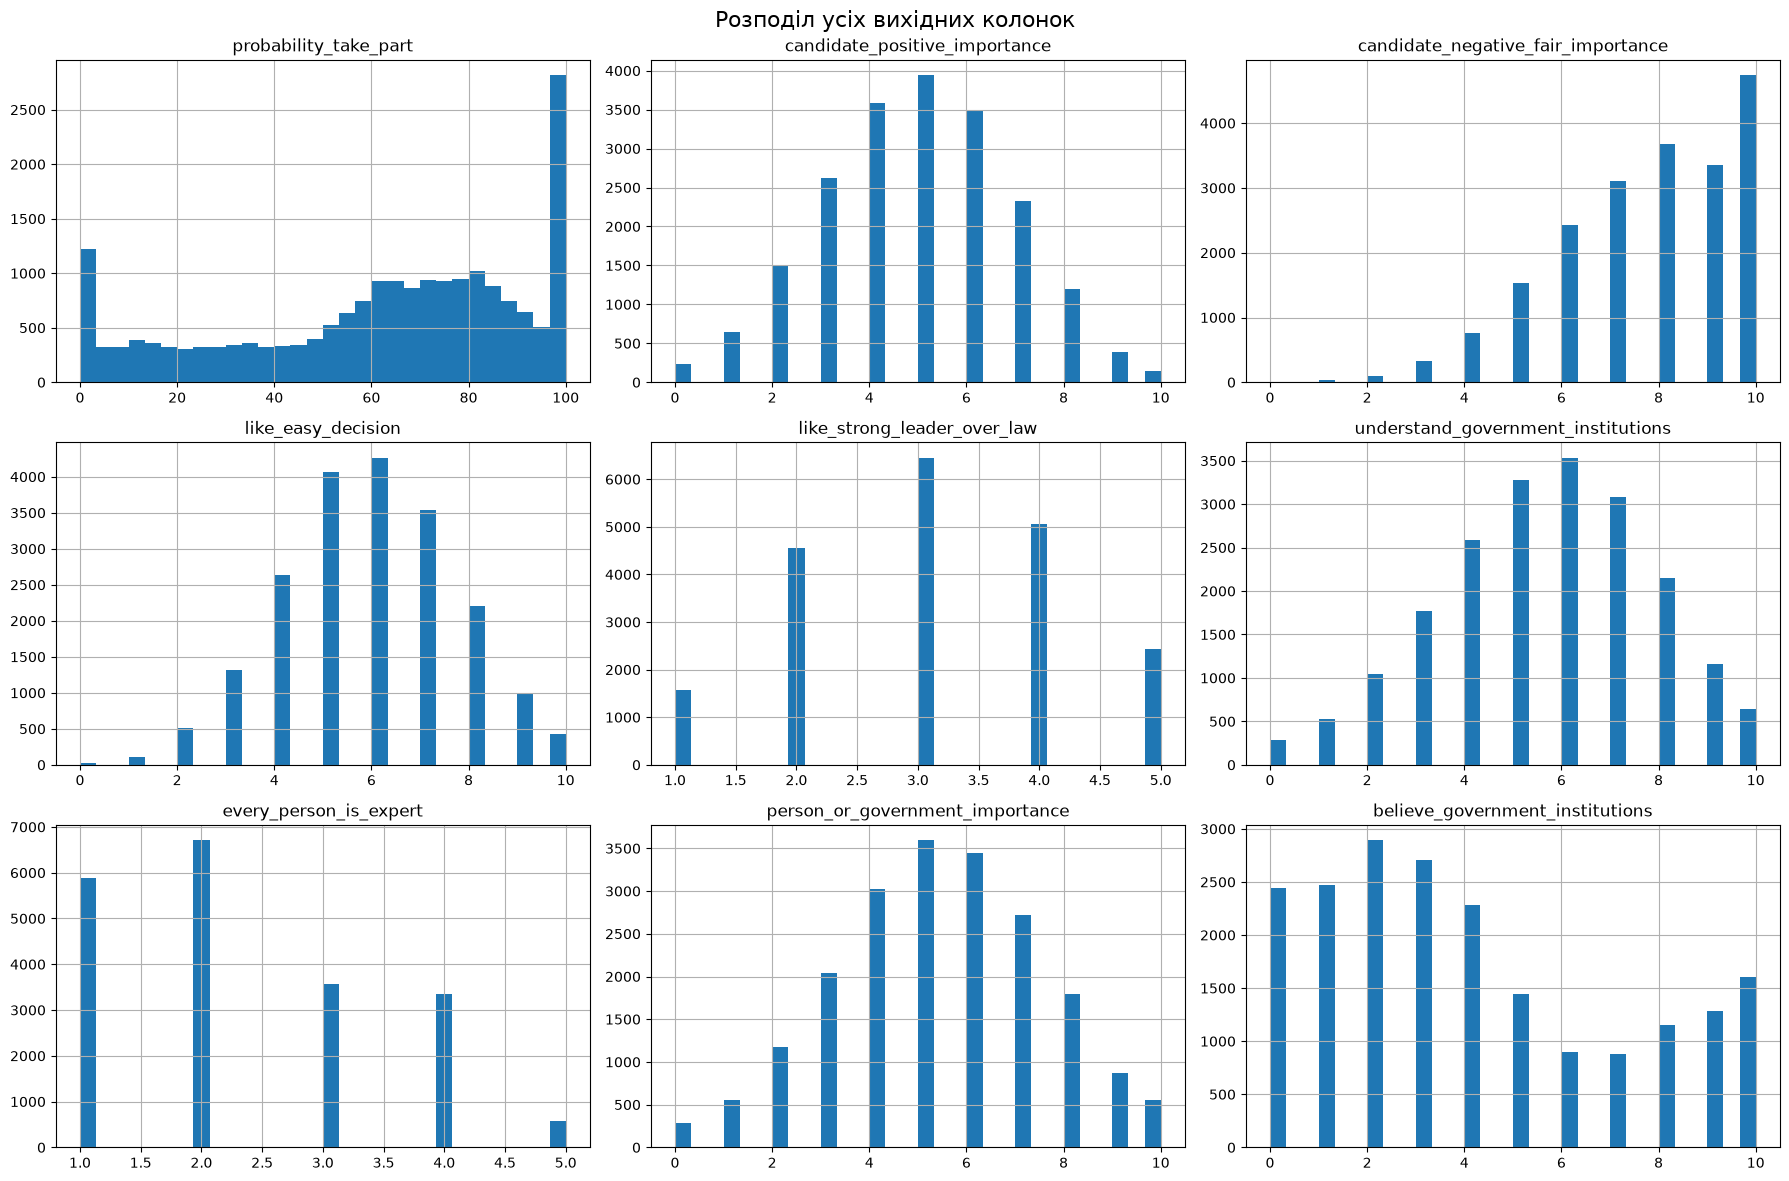

Матриця кореляцій між вихідними даними


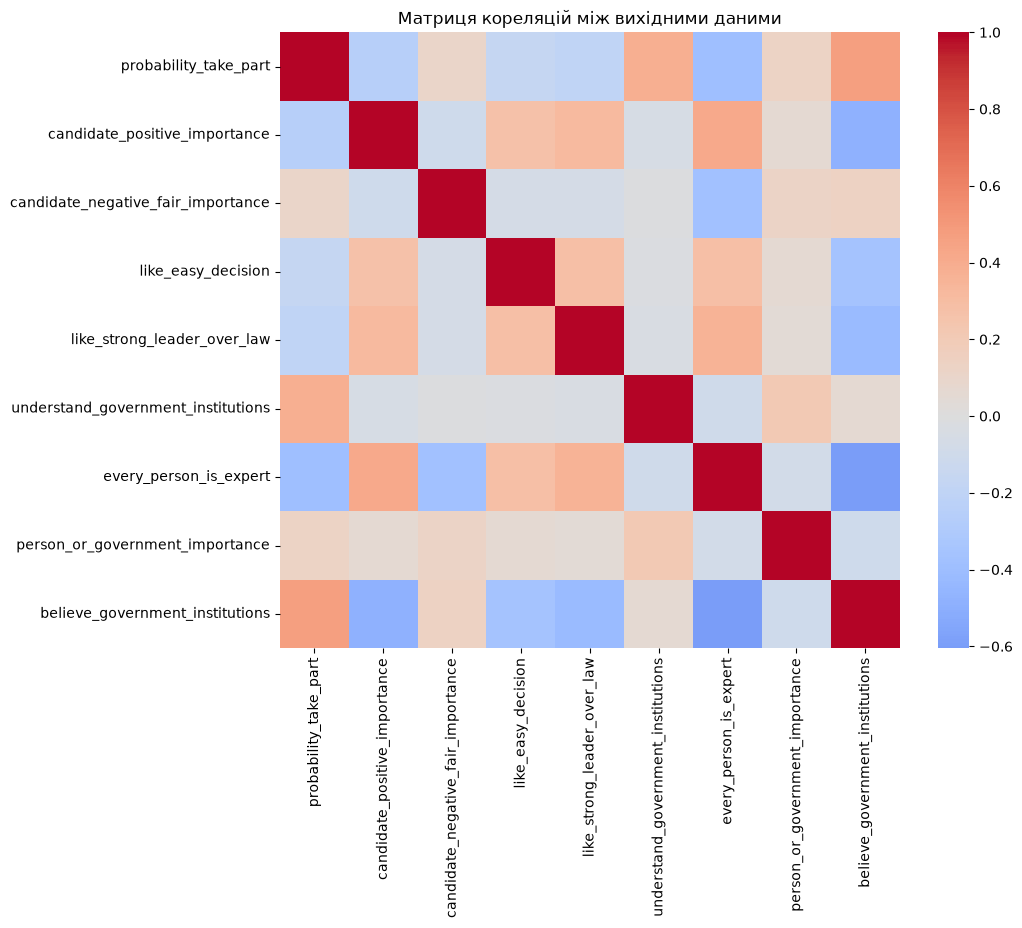

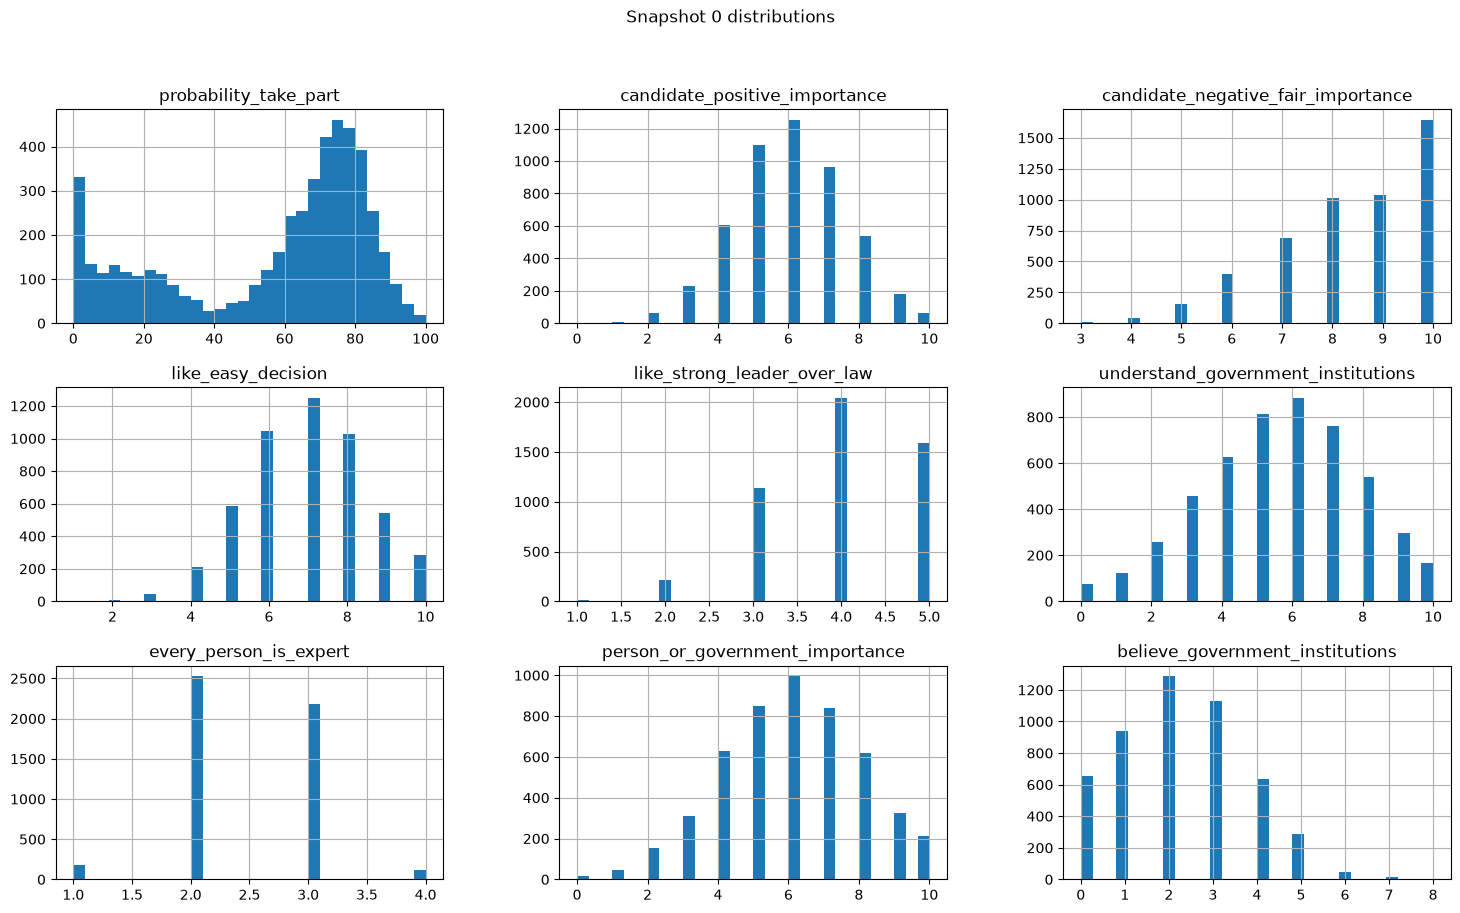

In [1]:
"""
GENERATE TRAINING DATA  (with country state)
======================================================
KEY CHANGE: country state fields are appended to every voter row.
This means the model learns HOW country context shifts voter preferences.

WHY BAKE COUNTRY INTO VOTER ROWS (not pass separately)?
  The model maps:  voter_profile + country_state  →  ideal_vector
  Different country states produce different ideal vectors for the
  same voter.

  Example:
    voter A in peace (war_status=1) → ideal_security = 4.2
    voter A in war   (war_status=9) → ideal_security = 8.7
    same voter, different country context, very different priorities.

COUNTRY FIELDS (all 0-10):
  war_status          0=peace       10=active war
  economic_crisis     0=stable      10=severe crisis
  corruption_level    0=clean       10=highly corrupt
  media_freedom       0=censored    10=free press
  political_stability 0=chaos       10=stable

TRAINING STRATEGY:
  Generating voters under MULTIPLE country states so the model
  learns the relationship, not just one scenario.
  Each voter is cloned across several country snapshots.

OUTPUT: data/non-linear-voters.csv
"""

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

import constants

from generate_voter_base import generate_voter_base
from generation_data import (
    COUNTRY_FIELDS,
    ECON_STATUS,
    EDUCATIONS,
    TARGET_COLS,
    COUNTRY_SNAPSHOTS,
)

Path("data").mkdir(exist_ok=True)
rng = np.random.default_rng(42)


def sigmoid(x, midpoint=5, steepness=1.0):
    """
    It is ideal for applications where probability estimation is needed
    The non-linear nature
    Saturation effects
    """
    return 1 / (1 + np.exp(-steepness * (x - midpoint)))


def interaction(a, b, scale=10):
    """
    Multiplicative interaction: two factors amplify each other.
    """
    return (a * b) / scale


def diminishing(x, scale=3.0):
    """
    Diminishing returns via square root.
    First units of x matter a lot, later units matter less.
    """
    return scale * np.sqrt(max(0, x))


# ══════════════════════════════════════════════════════════════════════════════
# NON-LINEAR TARGET DERIVATION
# ══════════════════════════════════════════════════════════════════════════════
def derive_targets(voter: dict, country: dict) -> dict:
    edu_idx = (
        EDUCATIONS.index(voter["education"]) if voter["education"] in EDUCATIONS else 1
    )
    eco_idx = (
        ECON_STATUS.index(voter["economic_status"])
        if voter["economic_status"] in ECON_STATUS
        else 2
    )
    und_avg = (
        voter["und_econ_num"] + voter["und_safety_num"] + voter["und_social_num"]
    ) / 3

    war = country["war_status"]
    econ = country["economic_crisis"]
    corr = country["corruption_level"]
    media = country["media_freedom"]
    stab = country["political_stability"]

    # ── 1. understand_government_institutions (0-10) ──────────────────────────
    edu_effect = diminishing(edu_idx, scale=2.0)
    und_effect = diminishing(und_avg, scale=1.5)
    gov_und = np.clip(
        edu_effect
        + und_effect
        + voter["political_interest"] * 0.35
        + rng.normal(0, 1.5),
        0,
        10,
    )
    understand_government_institutions = int(gov_und)

    # ── 2. believe_government_institutions (0-10) ─────────────────────────────
    trust_collapse = (1 - sigmoid(corr, midpoint=5.5, steepness=1.5)) * 6
    trust = np.clip(
        trust_collapse
        + stab * 0.35
        + media * 0.12
        + gov_und * 0.10
        + rng.normal(0, 1.5),
        0,
        10,
    )
    believe_government_institutions = int(trust)

    # ── 3. every_person_is_expert (1-5) ───────────────────────────────────────
    institutional_collapse = interaction(corr, 10 - stab, scale=10)
    populism_spike = sigmoid(institutional_collapse, midpoint=5, steepness=2.5) * 2.5
    pop = np.clip(
        1.0
        + populism_spike
        + diminishing(10 - gov_und, scale=0.2)
        + rng.normal(0, 0.5),
        1,
        5,
    )
    every_person_is_expert = int(round(pop))

    # ── 4. probability_take_part (0-100) ──────────────────────────────────────
    interest_effect = (
        sigmoid(voter["political_interest"], midpoint=3.5, steepness=2.0) * 72
    )
    urgency = interaction(war, econ, scale=4) * 1.5
    disillusion_raw = interaction(corr, 10 - stab, scale=10)
    disillusion = sigmoid(disillusion_raw, midpoint=4, steepness=1.5) * 35
    trust_bonus = trust * 3.2
    edu_eco_effect = diminishing(edu_idx, scale=3) + diminishing(eco_idx, scale=2)

    prob = np.clip(
        interest_effect
        + urgency
        + trust_bonus
        + edu_eco_effect
        - disillusion
        + rng.normal(0, 6),
        0,
        100,
    )
    probability_take_part = round(float(prob), 1)

    # ── 5. candidate_positive_importance (0-10) ───────────────────────────────
    censorship_effect = sigmoid(10 - media, midpoint=5, steepness=1.5) * 1.5
    pos_imp = np.clip(
        voter["media_positive_reaction"] * 0.45
        + diminishing(10 - und_avg, scale=0.7)
        + censorship_effect
        + interaction(war, 10 - media, scale=10) * 0.3
        + rng.normal(0, 1.3),
        0,
        10,
    )
    candidate_positive_importance = int(pos_imp)

    # ── 6. candidate_negative_fair_importance (0-10) ──────────────────────────
    need_truth = sigmoid(corr, midpoint=5, steepness=1.2) * 0.8
    access_truth = sigmoid(media, midpoint=4, steepness=1.0) * 0.8
    truth_effect = need_truth * access_truth * 5

    hopelessness = interaction(corr, 10 - media, scale=10)
    hope_penalty = sigmoid(hopelessness, midpoint=7, steepness=2.0) * 2.5

    neg_imp = np.clip(
        6.0
        + voter["media_negative_reaction"] * 0.20
        + diminishing(und_avg, scale=0.5)
        + truth_effect
        - hope_penalty
        + rng.normal(0, 1.8),
        0,
        10,
    )
    candidate_negative_fair_importance = int(neg_imp)

    # ── 7. like_easy_decision (0-10) ──────────────────────────────────────────
    simplicity_pull = sigmoid(10 - und_avg, midpoint=5, steepness=1.5) * 3.5
    instability_effect = interaction(war, 10 - stab, scale=10) * 0.4
    edu_effect_easy = diminishing(3 - edu_idx, scale=0.6) if edu_idx < 3 else 0
    media_neg_effect = voter["media_negative_reaction"] * 0.15

    easy = np.clip(
        1.5
        + simplicity_pull
        + instability_effect
        + edu_effect_easy
        - media_neg_effect
        + gov_und * 0.08
        + rng.normal(0, 1.5),
        0,
        10,
    )
    like_easy_decision = int(easy)

    # ── 8. like_strong_leader_over_law (1-5) ──────────────────────────────────
    war_instability = interaction(war, 10 - stab, scale=10)
    auth_spike = sigmoid(war_instability, midpoint=4, steepness=1.2) * 1.8

    understanding_pull = (1 - und_avg / 4) * 1.2

    auth = np.clip(
        1.5  # base
        + auth_spike
        + understanding_pull
        + corr * 0.06
        + rng.normal(0, 0.9),
        1,
        5,
    )
    like_strong_leader_over_law = int(round(auth))

    # ── 9. person_or_government_importance (0-10) ─────────────────────────────
    state_focus = sigmoid(war + econ, midpoint=8, steepness=1.0) * 3.0
    anti_state = sigmoid(corr, midpoint=7, steepness=1.2) * 3.0

    pers_gov = np.clip(
        3.5
        + state_focus
        - anti_state
        + voter["political_interest"] * 0.12
        + gov_und * 0.15
        + rng.normal(0, 2.0),
        0,
        10,
    )
    person_or_government_importance = int(pers_gov)

    return {
        "probability_take_part": probability_take_part,
        "candidate_positive_importance": candidate_positive_importance,
        "candidate_negative_fair_importance": candidate_negative_fair_importance,
        "like_easy_decision": like_easy_decision,
        "like_strong_leader_over_law": like_strong_leader_over_law,
        "understand_government_institutions": understand_government_institutions,
        "every_person_is_expert": every_person_is_expert,
        "person_or_government_importance": person_or_government_importance,
        "believe_government_institutions": believe_government_institutions,
    }


# ── Generate: each voter × each country snapshot ─────────────────────────────
N_BASE = (
    constants.N_BASE_GENERATE_VOTERS  # base voters; total rows = N_BASE × len(COUNTRY_SNAPSHOTS)
)
rows = []

for i in range(N_BASE):
    base = generate_voter_base(i)
    for snap_idx, country in enumerate(COUNTRY_SNAPSHOTS):
        row = dict(base)
        row["snapshot_id"] = snap_idx
        row["base_voter_id"] = i
        row["voter_id"] = i * len(COUNTRY_SNAPSHOTS) + snap_idx

        for field in COUNTRY_FIELDS:
            row[field] = country[field]

        row.update(derive_targets(row, country))

        del row["und_econ_num"]
        del row["und_safety_num"]
        del row["und_social_num"]

        rows.append(row)

synth_df = pd.DataFrame(rows)
synth_df["source"] = "synth"
n_synth = len(synth_df)


real_df = pd.read_csv(constants.REAL_DATASET_NAME)
real_df["probability_take_part"] = pd.to_numeric(
    real_df["probability_take_part"], errors="coerce"
).clip(0, 100)
real_df["source"] = "real"
real_df["snapshot_id"] = len(COUNTRY_SNAPSHOTS)
n_real = len(real_df)

start_id = len(synth_df)
real_df["voter_id"] = range(start_id, start_id + len(real_df))
real_df["base_voter_id"] = range(N_BASE, N_BASE + len(real_df))


all_cols = list(synth_df.columns.union(real_df.columns))
combined = pd.concat([synth_df, real_df], ignore_index=True)
total = len(combined)

out_path = constants.NON_LINEAR_VOTERS_OUTPUT
combined.to_csv(out_path, index=False)

print(f"Saved {total} total rows → {out_path}")
print(f"Real: {n_real}  |  Synthetic: {n_synth}")


print(f"   ({N_BASE} voters × {len(COUNTRY_SNAPSHOTS)} country snapshots)")
print(
    f"\nFeature columns: {len([c for c in combined.columns if c not in TARGET_COLS + ['voter_id'] + ['source'] + ['base_voter_id'] + ['snapshot_id']])}"
)
print(f"Target columns:  {len(TARGET_COLS)}")
print("\nTarget averages across all country contexts:")
for col in TARGET_COLS:
    print(
        f"  {col:<45s}  mean={combined[col].mean():.2f}  std={combined[col].std():.2f}"
    )


print("Розподіл усіх вихідних колонок")
target_cols = TARGET_COLS

combined[target_cols].hist(figsize=(18, 12), bins=30)
plt.suptitle("Розподіл усіх вихідних колонок", fontsize=16)
plt.tight_layout()
plt.show()

print("Матриця кореляцій між вихідними даними")
plt.figure(figsize=(10, 8))
corr = combined[target_cols].corr()

sns.heatmap(corr, annot=False, cmap="coolwarm", center=0)
plt.title("Матриця кореляцій між вихідними даними")
plt.show()

snap0 = combined[combined["snapshot_id"] == 0]
snap0[TARGET_COLS].hist(figsize=(18, 10), bins=30)
plt.suptitle("Snapshot 0 distributions")
plt.show()